# Denoising Autoencoder (DAE) for corrupted images

In this activity, I demonstrate the use of an autoencoder for reconstructing corrupted images using the Fashion-MNIST dataset. This example highlights an essential property of autoencoders: although they are trained to reproduce their input, they do so by learning an internal representation that captures the underlying structure of the data. As a result, they can correct noise, fill in missing information, and perform other tasks that go beyond simple copying.

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import fashion_mnist

## Loading and preparing the Dataset

I choose the Fashion-MNIST dataset, which contains 70000 28x28 labeled fashion images. The images are in gray scale. Here we can visualize some of them.

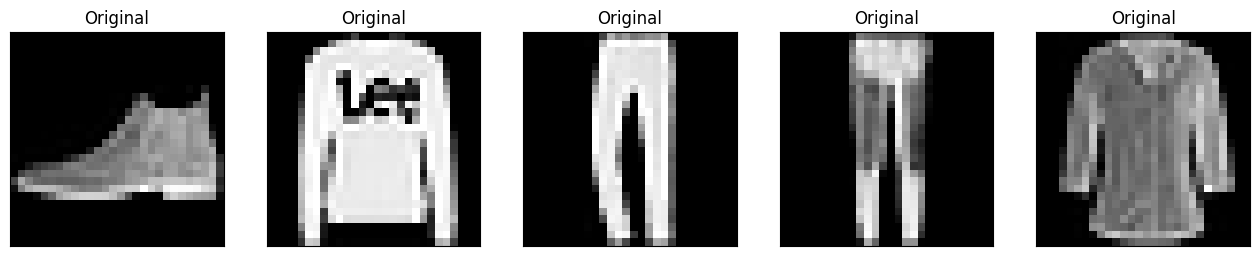

In [13]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()
n = 5
plt.figure(figsize=(16, 4))
for i in range(n):
    # Original Images
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Now we can add some gaussian noise to the images, in order to simulate some sort of corruption.

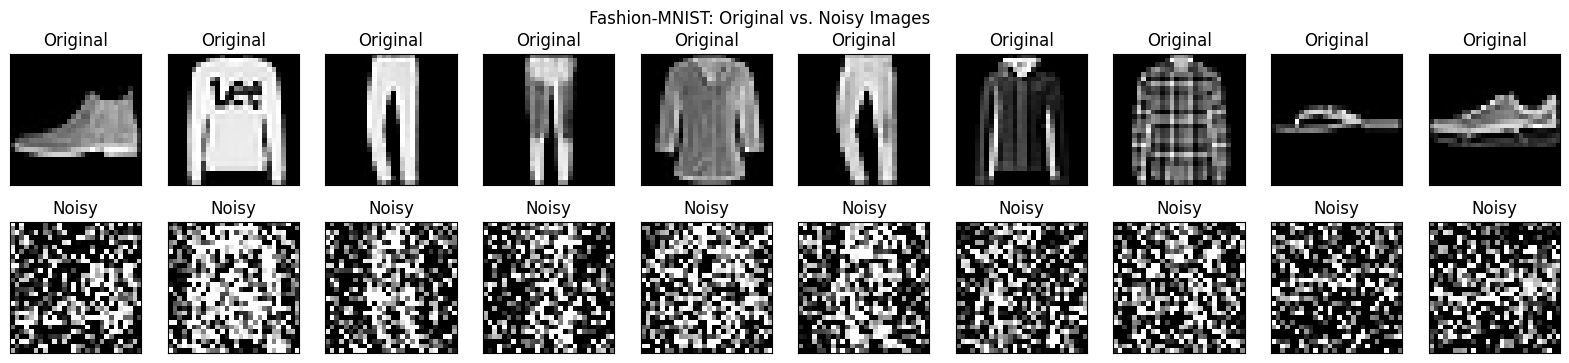

In [14]:
# Normalization (Scale to [0, 1])
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Create Noisy Data
noise_factor = 0.8
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
# Necessary to mantain the range between [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Visualize the original and noisy images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original Images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy Images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle('Fashion-MNIST: Original vs. Noisy Images')
plt.show()

We need to reshape our data because of the input of the autoencoder we are going to define in the next step. In particular, if we consider a single image, the shape is (28 x 28) but instead we need something like (784, ) in order to match the input of the feed forward neural networks that we'll define.

In [15]:
image_size = x_train.shape[1] * x_train.shape[2] # 28 * 28 = 784

x_train_flat = x_train.reshape((len(x_train), image_size))
x_train_noisy_flat = x_train_noisy.reshape((len(x_train_noisy), image_size))

x_test_flat = x_test.reshape((len(x_test), image_size))
x_test_noisy_flat = x_test_noisy.reshape((len(x_test_noisy), image_size))

print(f"Clean Training Data Shape (Original): {x_train.shape}")
print(f"Clean Training Data Shape (Flat): {x_train_flat.shape}")
print(f"Noisy Training Data Shape (Flat): {x_train_noisy_flat.shape}")

Clean Training Data Shape (Original): (60000, 28, 28)
Clean Training Data Shape (Flat): (60000, 784)
Noisy Training Data Shape (Flat): (60000, 784)


## Denoising Autoencoder

Autoencoders are an unsupervised learning technique based on
feed forward neural networks. The three main component of an autoencoder are:


*   Encoder: creates a new compressed representation (often called latent vector) of the input;
*   Decoder: reconstructs the input starting from the latent vector;
*   Bottleneck/Latent layer: it sits between the encoder and decoder, here all the most meaningful features of the data are being captured. It controls the level of compression in fact for a small latent space we have more compression.

In the easiest form an autoencoder has a single hidden layer $\mathbf{h}$, a set of parameters $\mathbf{W}, \mathbf{W}^{\prime}$ defined by two weight matrices and two bias vector:
 $$\mathbf{h} = f_{\mathbf{W}}(\mathbf{x}) = s_1(\mathbf{W}\mathbf{x} + \mathbf{b})$$
 $$\mathbf{\hat{x}} = g_{\mathbf{W}^\prime}(\mathbf{h}) = s_2(\mathbf{W}'\mathbf{h} + \mathbf{b}')$$

Where $s_1$ and $s_2$ are non linear activation function, $\mathbf{h}$ is the latent vector and $\mathbf{\hat{x}}$ is the reconstructed input.

So the loss function is the reconstruction loss for which we can use a mean squared error loss defined like this:
$$\mathbf{L}(\mathbf{x}, \mathbf{\tilde{x}}) = ||\mathbf{x} - \mathbf{\tilde{x}}||_2^2$$
where $\mathbf{\tilde{x}} = g_{\mathbf{W}'}(f_{\mathbf{W}}(\mathbf{x}))$

The final objective function to optimize is:
$$\mathbf{J}(\mathbf{W}, \mathbf{W}'; \mathbf{x}) = \sum_{\mathbf{x} \in \mathbf{X}} \mathbf{L}(\mathbf{x}, g_{\mathbf{W}'}(f_{\mathbf{W}}(\mathbf{x})))$$

In a denoising autoencoder, the encoder is able to detect patterns that are consistent despite the noise, discard irrelevant disturbances and capture clean features like edges, shapes and textures.

In this implementation we add more intermediate layers between the encoder and the latent layer, and between the latent layer and the decoder. Adding more layers smooth the compressions process and helps the network build more levels of abstraction. Non-linear transformations, such as ReLU and sigmoid, are applied between layers. The structure from input to output is symmetric, as an autoencoder is typically defined. I used Tensorflow Keras to define the network.

In [16]:
# Define the size of the input (28x28 = 784 pixels)
input_dim = 784

# Input
input_img = Input(shape=(input_dim,), name='input')

# Encoder
encoded = Dense(512, activation='relu', name='encoder1')(input_img)
encoded = Dense(256, activation='relu', name='encoder2')(encoded)

# This layer represents the latent space
latent_vector = Dense(128, activation='relu', name='latent_space')(encoded)

# Decoder
decoded = Dense(256, activation='relu', name='decoder4')(latent_vector)
decoded = Dense(512, activation='relu', name='decoder5')(decoded)

# Output
output_img = Dense(input_dim, activation='sigmoid', name='output')(decoded)

In [17]:
# Model definition
dae = Model(inputs=input_img, outputs=output_img, name='FullyConnected_DAE')

dae.summary()

# As we said before we use mse as loss
dae.compile(optimizer='adam', loss='mse')

Model: "FullyConnected_DAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder1 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder4 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder5 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,132,944 (4.32 MB)

 Trainable params: 1,132,944 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
print("Training Denoising Autoencoder...")
history = dae.fit(
    x_train_noisy_flat, # Input: Noisy images
    x_train_flat,       # Target: Clean images
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_flat, x_test_flat)
)

Training Denoising Autoencoder...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 0.0601 - val_loss: 0.0303
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - loss: 0.0284 - val_loss: 0.0275
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - loss: 0.0256 - val_loss: 0.0251
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - loss: 0.0239 - val_loss: 0.0244
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.0228 - val_loss: 0.0240
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.0220 - val_loss: 0.0232
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - loss: 0.0211 - val_loss: 0.0229
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - loss: 0.0205 - val_loss: 0.0227
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - loss: 0.0200 - val_loss: 0.0224
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.0195 - val_loss: 0.0224
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.0191 - val_loss: 0.0

We can plot the model loss to compare training and validation loss after each epoch. As observed, after about 10 epochs the validation loss stops improving, while the training loss continues to decrease. This suggests that the model has learned as much as it can from the data, and any further training starts to overfit to the training set rather than improving generalization.

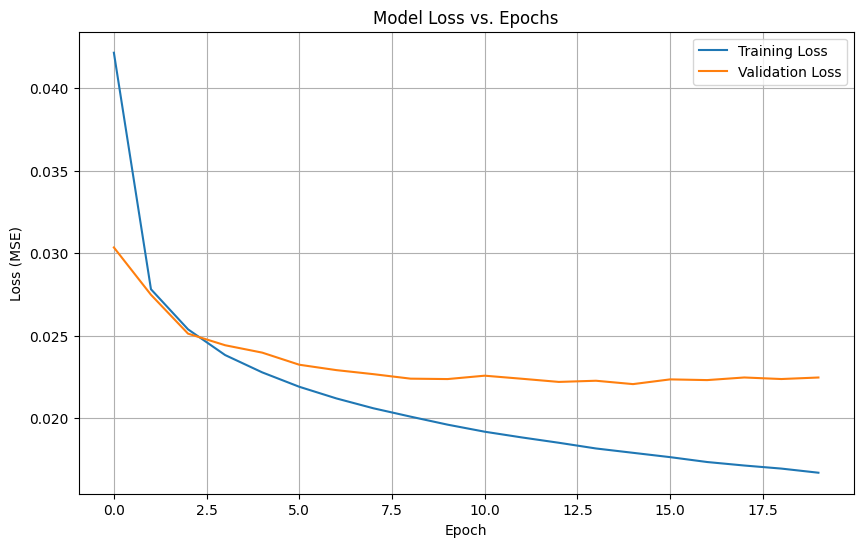

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss vs. Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

## Visualize the reconstructed inputs

First, we need to reshape our output back to the original shape (28x28).

In [20]:
reconstructed_inputs = dae.predict(x_test_noisy_flat)

print(f"Prediction output shape (flattened vectors): {reconstructed_inputs.shape}")

# Original image size
img_rows, img_cols = 28, 28
denoised_images = reconstructed_inputs.reshape((len(reconstructed_inputs), img_rows, img_cols))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediction output shape (flattened vectors): (10000, 784)


Now we can plot our denoised images and comparing them with original and noisy images.

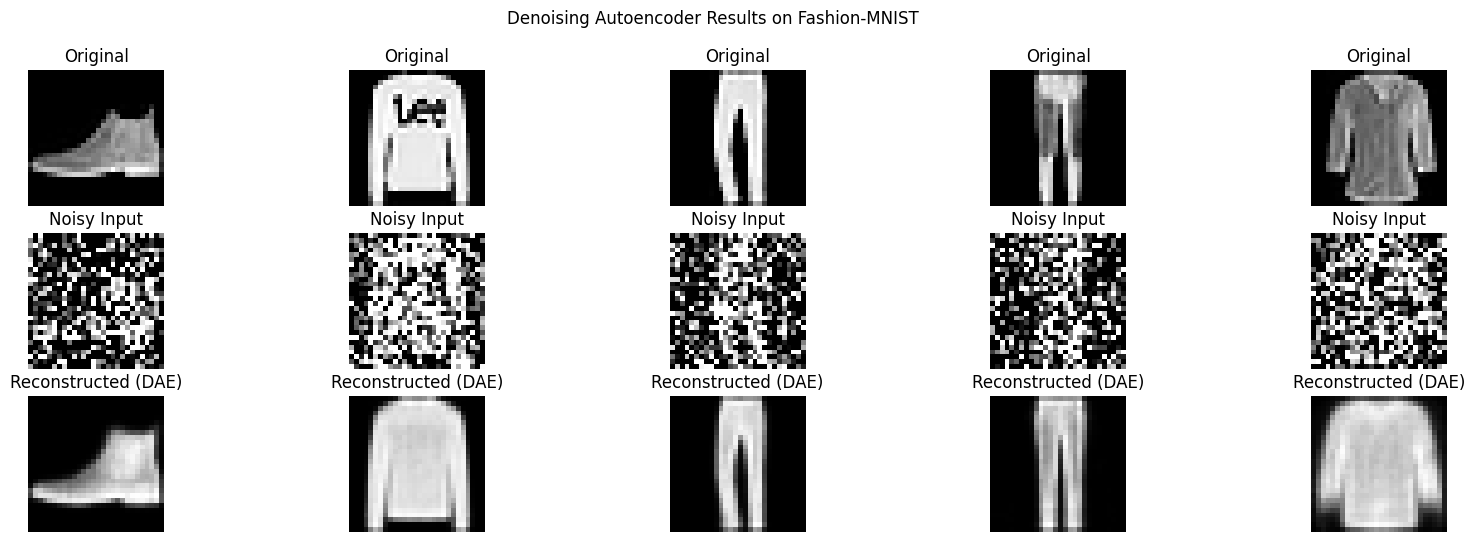

In [21]:
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(20, 6))
for i in range(n):
    original_image = x_test[i]
    noisy_image = x_test_noisy[i]
    reconstructed_image = denoised_images[i]

    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(original_image, cmap='gray')
    ax.set_title("Original")
    ax.axis('off')

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_image, cmap='gray')
    ax.set_title("Noisy Input")
    ax.axis('off')

    # Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(reconstructed_image, cmap='gray')
    ax.set_title("Reconstructed (DAE)")
    ax.axis('off')

plt.suptitle('Denoising Autoencoder Results on Fashion-MNIST')
plt.show()

As we can see, the denoising autoencoder successfully reconstructs the main patterns of the images, including edges and the overall structure. However, some fine details are lost in the reconstruction. This could be because of the model architecture, which may not provide sufficient depth, capacity, or resolution in the latent space to capture more subtle textures and high-frequency information.

### Reconstruction Error Map

Instead of just looking at the reconstructed image, we can plot the difference between the clean original image and the reconstructed image. This map highlights where the autoencoder struggles the most.

$$\text{Error Map} = |\text{Original Image} - \text{Reconstructed Image}|$$

Areas with high error (bright pixels) indicate parts of the image the model failed to reconstruct in a accurate way. Areas with low error (more black/dark color) indicate perfect reconstruction.

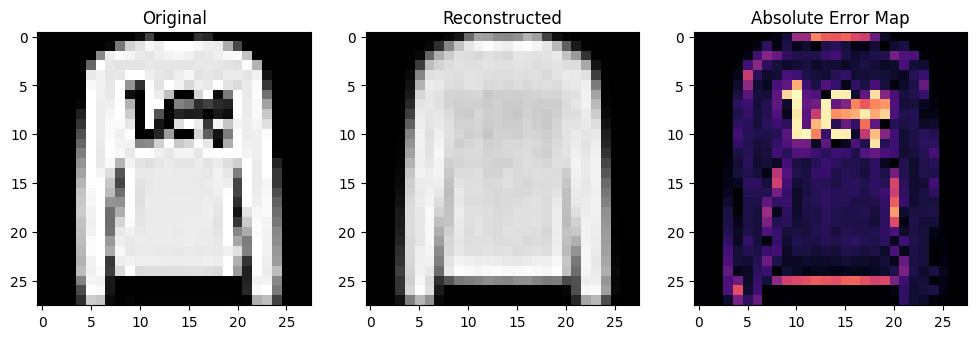

In [22]:
sample_index = 1
original = x_test[sample_index]
reconstructed = denoised_images[sample_index]

# Calculate the absolute difference
error_map = np.abs(original - reconstructed)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1).imshow(original, cmap='gray'); plt.title('Original')
plt.subplot(1, 3, 2).imshow(reconstructed, cmap='gray'); plt.title('Reconstructed')
plt.subplot(1, 3, 3).imshow(error_map, cmap='magma'); plt.title('Absolute Error Map')
plt.show()

# References

Slide Lez14 - Representation Learning

https://www.tensorflow.org/guide/keras/functional_api

# Use of AI assistant
I used AI assistant to help me with english language in order to write better some sentences.